In [204]:
from sklearn.datasets import make_regression
import numpy as np 
from sklearn.model_selection import cross_val_score

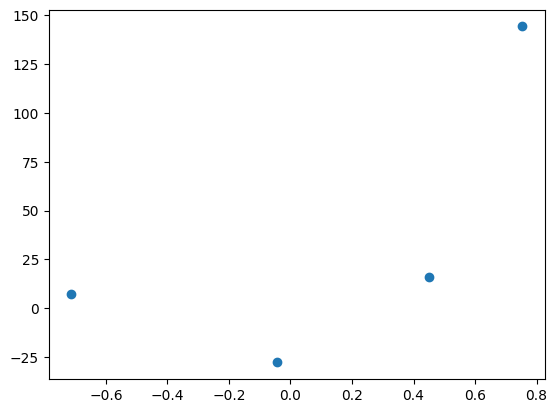

In [205]:
X,y = make_regression(n_samples=4,n_features=1,n_informative=1,n_targets=1,noise=80,random_state=13)


import matplotlib.pyplot as plt 
plt.scatter(X,y)

In [206]:
from sklearn.linear_model import LinearRegression


In [207]:
reg = LinearRegression()
reg.fit(X,y)


LinearRegression()

In [208]:
reg.coef_

array([78.35063668])

In [209]:
reg.intercept_

26.15963284313262

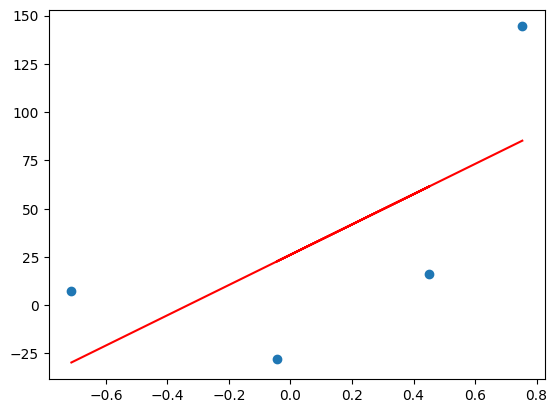

In [210]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red')


In [211]:
# lets aply gradient descent assuming slope is constant m = 78.35
# and assume starting value of b = 0
y_pred = ((78.35*X)+0).reshape(4)

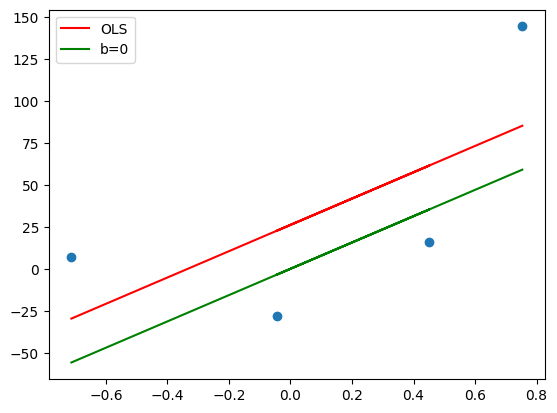

In [212]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred,color='green',label='b=0')
plt.legend()
plt.show()

In [213]:
m=78.35
b = 0

loss_slope = -2*np.sum(y-m*X.ravel()-b)
loss_slope

-209.27763408209216

In [214]:
# learning rate = 0.1
lr=0.1
step_size = loss_slope*lr
step_size

-20.927763408209216

In [215]:
# cal new intercept
b_new = b - step_size
b_new

20.927763408209216

In [216]:
y_pred = ((78.35*X)+b_new).reshape(4)

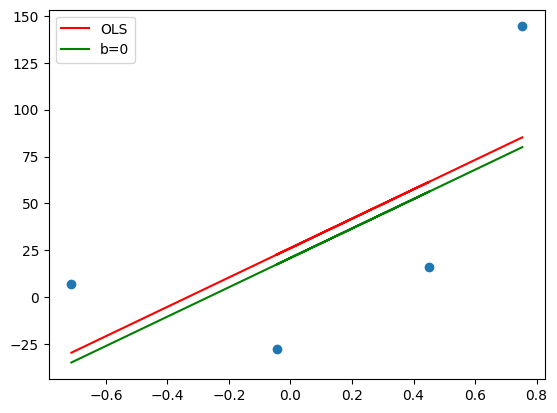

In [217]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred,color='green',label='b=0')
plt.legend()
plt.show()

In [218]:
loss_slope = -2*np.sum(y-m*X.ravel()-b_new)
loss_slope

-41.85552681641843

In [219]:
step_size = loss_slope*lr
step_size

-4.185552681641844

In [220]:
# cal new intercept
b_new = b - step_size
b_new

4.185552681641844

In [221]:
y_pred = ((78.35*X)+b_new).reshape(4)
y_pred

array([-51.63025569,  39.58504942,   0.69873649,  63.24314845])

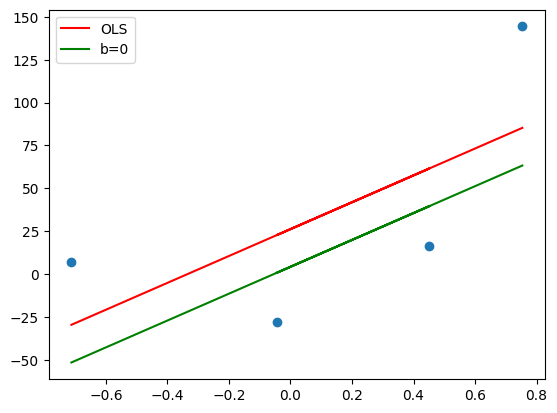

In [222]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred,color='green',label='b=0')
plt.legend()
plt.show()

In [223]:
loss_slope = -2*np.sum(y-m*X.ravel()-b_new)
loss_slope

-175.7932126289574

In [224]:
step_size = loss_slope*lr
step_size

-17.579321262895743

In [225]:
# cal new intercept
b_new = b - step_size
b_new

17.579321262895743

In [226]:
y_pred = ((78.35*X)+b_new).reshape(4)
y_pred

array([-38.23648711,  52.978818  ,  14.09250508,  76.63691703])

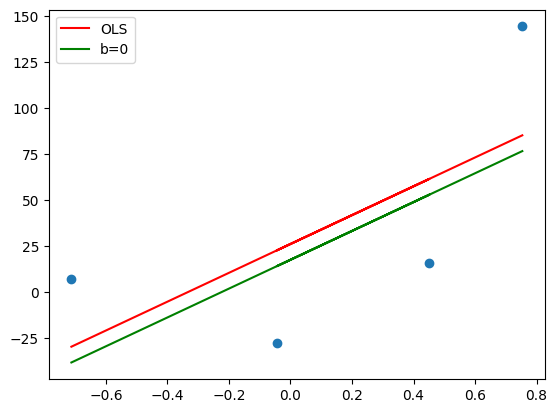

In [227]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred,color='green',label='b=0')
plt.legend()
plt.show()

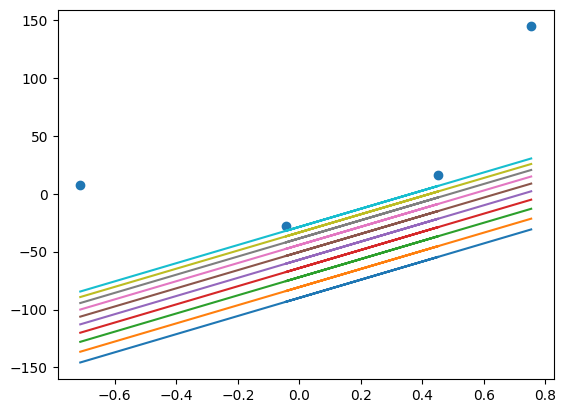

In [228]:
b = -100
m=78.35
epochs = 10
lr=0.01
for i in range(epochs):
    loss_slope = -2*np.sum(y-m*X.ravel()-b)
    b = b-(lr*loss_slope)
    y_pred = m*X +b
    plt.plot(X,y_pred)
plt.scatter(X,y)

In [229]:
from sklearn.datasets import make_regression


In [230]:
X,y = make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=20,random_state=13)

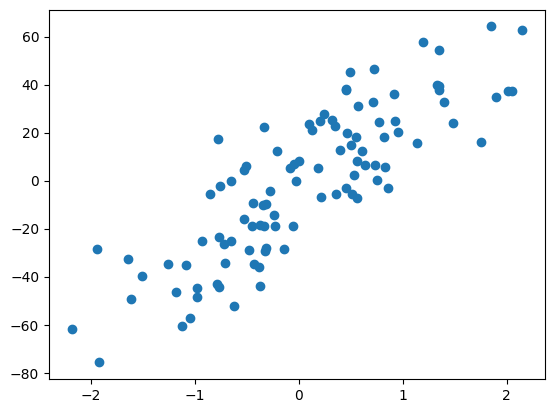

In [231]:
plt.scatter(X,y)

In [232]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [233]:
lr.fit(X,y)


LinearRegression()

In [234]:
lr.coef_

array([27.82809103])

In [235]:
lr.intercept_

-2.2947445586769795

In [236]:
m = 27.82
b = -2.29


In [237]:
np.mean(cross_val_score(lr,X,y,scoring='r2',cv=5))

0.6669521215791286

In [238]:
import numpy as np

class GDregressor:
    
    def __init__(self, learning_rate, epochs):
        self.m = 0
        self.b = 0
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self, X, y):
        X = X.ravel()
        
        for i in range(self.epochs):
            
            n = len(X)
            y_pred = self.m * X + self.b

            dm = (-2/n) * np.sum(X * (y - y_pred))
            db = (-2/n) * np.sum(y - y_pred)

            
            self.m = self.m - self.lr * dm
            self.b = self.b - self.lr * db
        
        print("Final m:", self.m)
        # print(X.min(), X.max())

        print("Final b:", self.b)
    def predict(self,X):
        return self.m * X +self.b


In [239]:
gd = GDregressor(0.1, 50)


In [240]:
gd.fit(X,y)

Final m: 27.825794004412778
Final b: -2.2939458798531085


In [241]:
gd.predict(X)

array([[-22.11678169],
       [-14.45787084],
       [-14.91996617],
       [ 24.21932242],
       [  4.32463733],
       [ 21.66994441],
       [ -9.06469204],
       [  2.85232204],
       [-22.35633427],
       [-14.25617352],
       [ 53.78117367],
       [  8.75960944],
       [  3.4882556 ],
       [ -8.76138032],
       [-23.68160303],
       [ 10.31555234],
       [ 15.51133375],
       [  7.71032571],
       [-47.23560736],
       [ 46.38009583],
       [-24.24819196],
       [-16.53978113],
       [-28.12561064],
       [ 57.5421676 ],
       [ -8.06361587],
       [-47.90302149],
       [-11.71626766],
       [-11.2572924 ],
       [-15.68848774],
       [-16.85140555],
       [ 17.79530509],
       [ 19.0181372 ],
       [ 10.32452413],
       [-37.39913303],
       [-63.15216494],
       [-35.27916547],
       [  3.7568192 ],
       [ 34.7231788 ],
       [-32.54563687],
       [ 13.35143253],
       [-44.39006242],
       [ -2.36042241],
       [-10.03325964],
       [ 10

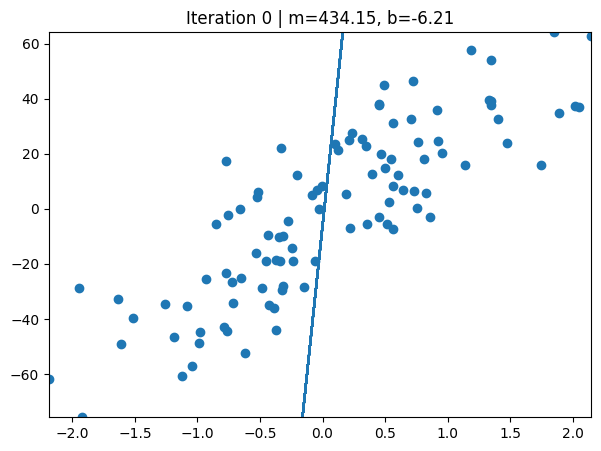

In [245]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# ---------- Your Data ----------
X = X.ravel()   # make sure 1D
n = len(X)

# ---------- Hyperparameters ----------
lr = 0.1
epochs = 100

# ---------- Initialize ----------
m = 520
b = 0

m_history = []
b_history = []

# ---------- Gradient Descent ----------
for i in range(epochs):
    
    y_pred = m * X + b
    
    dm = (-2/n) * np.sum(X * (y - y_pred))
    db = (-2/n) * np.sum(y - y_pred)
    
    m = m - lr * dm
    b = b - lr * db
    
    m_history.append(m)
    b_history.append(b)

# ---------- Animation ----------
fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(X, y)

line, = ax.plot(X, m_history[0] * X + b_history[0])

ax.set_xlim(X.min(), X.max())
ax.set_ylim(y.min(), y.max())

def update(frame):
    line.set_ydata(m_history[frame] * X + b_history[frame])
    ax.set_title(f"Iteration {frame} | m={m_history[frame]:.2f}, b={b_history[frame]:.2f}")
    return line,

ani = FuncAnimation(fig, update, frames=len(m_history), interval=200)

HTML(ani.to_jshtml())
